# 04 — Modeling: dau

Эксперимент по выбору модели и гиперпараметров для прогнозирования метрики **dau** на двух приложениях (Flood-It! и Flood-It! 2). Все решения принимаются ТОЛЬКО на обучающей выборке (без leakage); результат сохраняется в `results/final_config.json`.

## 0. Контекст

**Таргет:** dau = ежедневная активная аудитория, единицы — пользователи, диапазон > 0.

**Гипотезы:**
- RF/XGBoost могут выиграть за счёт нелинейных взаимодействий между install / uninstall сигналами и MAU.
- NW/LL — конкурентоспособны при достаточном bandwidth.
- При n_train≈88 ожидаем разумный ориентир R² ~0.5+.

**Особенность:** dau ~ MAU (корреляция ~0.85 в полном датасете), поэтому VIF-фильтр обязан выкинуть один из них.

In [1]:
import sys
from pathlib import Path

# Корень проекта в sys.path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

from src.feature_engineering import load_dataset, select_features as select_leaky
from src.kernel_regression import NadarayaWatsonRegressor, LocalLinearRegressor
from src.evaluation import compute_regression_metrics, diebold_mariano_test
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    chronological_split, select_features_clean, build_xy,
    fit_predict_evaluate, update_final_config,
    DEFAULT_OPERATIONAL_WHITELIST,
)

theme_setup()
np.random.seed(42)

TARGET = "dau"
NOTEBOOK_SLUG = f"04_modeling_{TARGET}"
APP_F1 = "com.labpixies.flood"
APP_F2 = "com.google.flood2"


In [2]:
# ── Конфигурация эксперимента (единственное место для редактирования при клонировании) ─────
D_GRID = [3, 5, 8, 10, 12, 15]
BW_GRID = np.logspace(-2, 1, 20)

# CV-стратегия: KFold(shuffle=True) для stickiness/dau; TimeSeriesSplit(5) для retention_d7
def make_cv():
    return KFold(n_splits=5, shuffle=True, random_state=42)

CV_STRATEGY_LABEL = 'KFold(5,shuffle=True,seed=42)'


## 1. Загрузка и валидация

Sanity-проверки: даты отсортированы внутри каждого app_id, target не весь NaN, оба ожидаемых app_id присутствуют.

In [3]:
df = load_dataset()
print(f"Размер датасета: {df.shape}")

# Проверки
assert {APP_F1, APP_F2}.issubset(df["app_id"].unique()), "Не все app_id найдены"
for app in [APP_F1, APP_F2]:
    sub = df[df["app_id"] == app].sort_values("date")
    assert sub["date"].is_monotonic_increasing, f"date не монотонна для {app}"
assert df[TARGET].notna().sum() >= 100, f"Слишком мало непустых {TARGET}"

print(f"app_id уникальные: {df['app_id'].unique().tolist()}")
print(f"Период: {df['date'].min()} — {df['date'].max()}")
print(f"Не-NaN {TARGET}: {df[TARGET].notna().sum()}")


Размер датасета: (222, 60)
app_id уникальные: ['com.google.flood2', 'com.labpixies.flood']
Период: 2018-06-12 00:00:00 — 2018-09-30 00:00:00
Не-NaN dau: 222


## 2. Per-app split (хронологический 80/20)

Делим каждое приложение на train (первые 80% дней) и test (последние 20%). Все дальнейшие решения принимаются ТОЛЬКО на train; test трогается лишь в финальной оценке (секция 7).

In [4]:
df_f1 = df[df["app_id"] == APP_F1].sort_values("date").reset_index(drop=True)
df_f2 = df[df["app_id"] == APP_F2].sort_values("date").reset_index(drop=True)

df_tr_f1, df_te_f1 = chronological_split(df_f1, test_frac=0.2)
df_tr_f2, df_te_f2 = chronological_split(df_f2, test_frac=0.2)

split_summary = pd.DataFrame([
    {"app": "f1 (Flood-It!)",
     "n_train": len(df_tr_f1), "n_test": len(df_te_f1),
     "train_period": f"{df_tr_f1['date'].min().date()} — {df_tr_f1['date'].max().date()}",
     "test_period":  f"{df_te_f1['date'].min().date()} — {df_te_f1['date'].max().date()}"},
    {"app": "f2 (Flood-It! 2)",
     "n_train": len(df_tr_f2), "n_test": len(df_te_f2),
     "train_period": f"{df_tr_f2['date'].min().date()} — {df_tr_f2['date'].max().date()}",
     "test_period":  f"{df_te_f2['date'].min().date()} — {df_te_f2['date'].max().date()}"},
])
print(split_summary.to_string(index=False))


             app  n_train  n_test            train_period             test_period
  f1 (Flood-It!)       88      23 2018-06-12 — 2018-09-07 2018-09-08 — 2018-09-30
f2 (Flood-It! 2)       88      23 2018-06-12 — 2018-09-07 2018-09-08 — 2018-09-30


## 3. Демонстрация leakage (педагогический раздел)

Сравниваем два набора признаков:
- **LEAKY**: `src.feature_engineering.select_features` запущен на ПОЛНОМ df_f1 — видит test внутри (как в текущем pipeline).
- **CLEAN**: `select_features_clean` запущен ТОЛЬКО на df_tr_f1.

Финальная NW(d=15) обучается на одинаковом train, оценивается на одинаковом test, разница только в наборе признаков. Дельта R²/RMSE — оценка leakage-bias.

In [5]:
def _leakage_compare(df_full, df_train, df_test, app_label_str):
    # Получаем leaky-имена признаков (но не X/y — те leaky по построению)
    _, _, fnames_leaky = select_leaky(df_full, target=TARGET, max_features=15)
    # Получаем clean-имена признаков (только на train)
    fnames_clean = select_features_clean(df_train, target=TARGET, max_features=15)

    # ОДИН И ТОТ ЖЕ split, разница только в наборе признаков
    def _eval_with_features(fnames):
        X_tr, y_tr, medians = build_xy(df_train, TARGET, fnames)
        X_te, y_te, _ = build_xy(df_test, TARGET, fnames, train_medians=medians)
        sc = StandardScaler().fit(X_tr)
        nw = NadarayaWatsonRegressor(kernel='gaussian', bandwidth=1.0)
        nw.fit(sc.transform(X_tr), y_tr)
        pred = nw.predict(sc.transform(X_te))
        return compute_regression_metrics(y_pred=pred, y_true=y_te,
                                          target_name=TARGET, y_train=y_tr)

    metrics_l = _eval_with_features(fnames_leaky)
    metrics_c = _eval_with_features(fnames_clean)

    jaccard = (len(set(fnames_leaky) & set(fnames_clean)) /
               len(set(fnames_leaky) | set(fnames_clean)))
    return {
        'app': app_label_str,
        'jaccard_features': round(jaccard, 3),
        'leaky_R2':   round(metrics_l['r2'], 4),
        'clean_R2':   round(metrics_c['r2'], 4),
        'delta_R2':   round(metrics_l['r2'] - metrics_c['r2'], 4),
        'leaky_RMSE': round(metrics_l['rmse'], 5),
        'clean_RMSE': round(metrics_c['rmse'], 5),
        # СОХРАНИМ unrounded для C2-фикса в _build_decision
        '_unrounded_delta_r2':   metrics_l['r2'] - metrics_c['r2'],
        '_unrounded_delta_rmse': metrics_l['rmse'] - metrics_c['rmse'],
    }, fnames_leaky, fnames_clean

leakage_f1, fnames_leaky_f1, fnames_clean_f1 = _leakage_compare(df_f1, df_tr_f1, df_te_f1, 'f1')
leakage_f2, fnames_leaky_f2, fnames_clean_f2 = _leakage_compare(df_f2, df_tr_f2, df_te_f2, 'f2')

leakage_df = pd.DataFrame([
    {k: v for k, v in row.items() if not k.startswith('_')}
    for row in [leakage_f1, leakage_f2]
])
print(leakage_df.to_string(index=False))

print('\nf1 leaky-only features:', set(fnames_leaky_f1) - set(fnames_clean_f1))
print('f1 clean-only features:', set(fnames_clean_f1) - set(fnames_leaky_f1))


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


app  jaccard_features  leaky_R2  clean_R2  delta_R2  leaky_RMSE  clean_RMSE
 f1             0.765   -1.5229   -1.6971    0.1742   127.89747   132.23936
 f2             0.579    0.0676   -1.2603    1.3279    80.09796   124.71108

f1 leaky-only features: {'seasonality_change', 'competition_volatility_7d'}
f1 clean-only features: {'median_session_duration', 'media_coverage_change'}


## 4. Кривая d → CV-RMSE для NW

Для каждого d ∈ {3, 5, 8, 10, 12, 15}:
1. Отбираем d признаков на train.
2. Подбираем bandwidth через CV на train.
3. Вычисляем CV-RMSE с этим bandwidth.

Выбор d* по 1-SE rule: минимум CV-RMSE + 1·std → берём наименьшее d, попадающее под этот порог.

In [6]:
def _d_sweep(df_train, app_label_str):
    cv = make_cv()
    rows = []
    for d in D_GRID:
        fnames = select_features_clean(df_train, target=TARGET, max_features=d)
        X_tr, y_tr, _ = build_xy(df_train, TARGET, fnames)
        sc = StandardScaler().fit(X_tr)
        X_tr_sc = sc.transform(X_tr)

        # Подбор bw на этом наборе d признаков
        nw = NadarayaWatsonRegressor(kernel="gaussian", bandwidth=1.0)
        bw_optimal = nw.bandwidth_cv(X_tr_sc, y_tr, cv=cv, bandwidths=BW_GRID,
                                     random_state=42)

        # CV-RMSE с зафиксированным bw
        scores = []
        for tr_idx, va_idx in cv.split(X_tr_sc):
            m = NadarayaWatsonRegressor(kernel="gaussian", bandwidth=bw_optimal)
            m.fit(X_tr_sc[tr_idx], y_tr[tr_idx])
            pred = m.predict(X_tr_sc[va_idx])
            scores.append(np.sqrt(mean_squared_error(y_tr[va_idx], pred)))
        rows.append({
            "d": d, "bw": round(bw_optimal, 4),
            "rmse_mean": float(np.mean(scores)),
            "rmse_std": float(np.std(scores)),
            "fnames": fnames,
        })
    df_curve = pd.DataFrame(rows)
    df_curve["app"] = app_label_str
    return df_curve

curve_f1 = _d_sweep(df_tr_f1, "f1")
curve_f2 = _d_sweep(df_tr_f2, "f2")
curve_full = pd.concat([curve_f1, curve_f2], ignore_index=True)
print(curve_full.drop(columns=["fnames"]).to_string(index=False))


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,


C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


 d     bw  rmse_mean  rmse_std app
 3 0.5456  53.756779  7.824847  f1
 5 0.5456  50.683667  7.709285  f1
 8 0.5456  59.007859  6.949715  f1
10 0.5456  59.041884 11.564722  f1
12 0.5456  60.887657 11.371166  f1
15 0.5456  59.549049 12.075861  f1
 3 0.7848  63.604711 30.767667  f2
 5 0.7848  59.043702 25.891838  f2
 8 0.7848  70.702056 45.806392  f2
10 0.7848  72.297713 42.609928  f2
12 0.7848  88.546671 41.243511  f2
15 1.1288  83.269724 37.607906  f2


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,


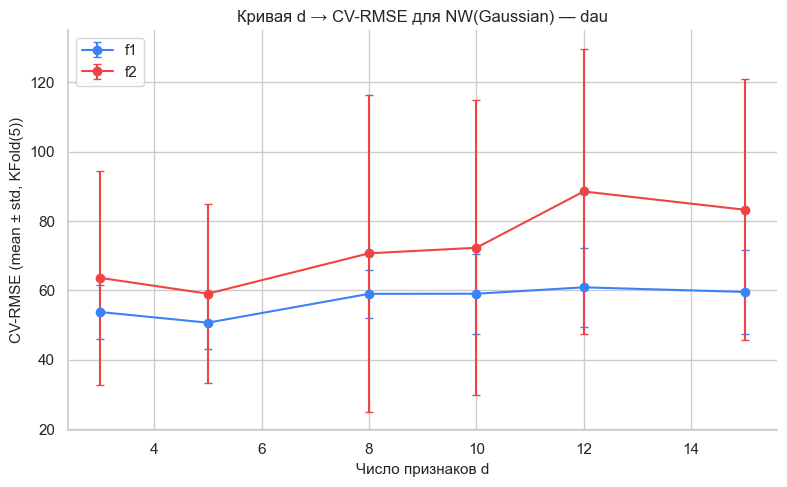

In [7]:
# График d → CV-RMSE
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
for app_key, color in [("f1", APP_PALETTE[APP_F1]), ("f2", APP_PALETTE[APP_F2])]:
    sub = curve_full[curve_full["app"] == app_key]
    ax.errorbar(sub["d"], sub["rmse_mean"], yerr=sub["rmse_std"],
                marker="o", label=app_key, color=color, capsize=3)
ax.set_xlabel("Число признаков d")
ax.set_ylabel("CV-RMSE (mean ± std, KFold(5))")
ax.set_title(f"Кривая d → CV-RMSE для NW(Gaussian) — {TARGET}")
ax.legend()
plt.tight_layout()
save_figure("d_curve_nw", NOTEBOOK_SLUG)
plt.show()


In [8]:
# Выбор d* по 1-SE rule per app
def _pick_d_star(df_curve):
    best = df_curve.loc[df_curve["rmse_mean"].idxmin()]
    threshold = best["rmse_mean"] + best["rmse_std"]
    candidates = df_curve[df_curve["rmse_mean"] <= threshold].sort_values("d")
    chosen = candidates.iloc[0]
    return int(chosen["d"]), chosen["fnames"], float(chosen["bw"])

d_star_f1, fnames_d_f1, bw_d_f1 = _pick_d_star(curve_f1)
d_star_f2, fnames_d_f2, bw_d_f2 = _pick_d_star(curve_f2)
print(f"d* f1 = {d_star_f1} (bw={bw_d_f1}), признаки: {fnames_d_f1}")
print(f"d* f2 = {d_star_f2} (bw={bw_d_f2}), признаки: {fnames_d_f2}")


d* f1 = 3 (bw=0.5456), признаки: ['dau_growth_rate', 'dau_growth_rate_7d', 'crash_rate', 'onboarding_completion_rate', 'median_session_duration']
d* f2 = 3 (bw=0.7848), признаки: ['seasonality_change', 'avg_session_duration_ma7', 'dau_growth_rate_7d', 'crash_rate', 'crash_rate_ma7', 'onboarding_completion_rate', 'avg_session_duration', 'median_session_duration']


## 5. Sweep моделей при d = d*

Для каждого приложения сравниваем 7 моделей на CV-RMSE (KFold(5, shuffle=True, seed=42)):
- **Локальные:** NadarayaWatson, LocalLinear, kNN (k подобран на train)
- **Линейные:** Ridge(α=1), ElasticNet (α, l1 через ElasticNetCV)
- **Деревянные:** RandomForest(100), XGBoost(100, depth=4)

Победитель по минимуму CV-RMSE.

In [9]:
def _knn_optimal_k(X, y, cv):
    from sklearn.metrics import mean_squared_error as _mse
    best_k, best_rmse = 5, np.inf
    for k in [5, 10]:
        scores = []
        for tr_idx, va_idx in cv.split(X):
            m = KNeighborsRegressor(n_neighbors=k)
            m.fit(X[tr_idx], y[tr_idx])
            scores.append(np.sqrt(_mse(y[va_idx], m.predict(X[va_idx]))))
        rmse = float(np.mean(scores))
        if rmse < best_rmse:
            best_k, best_rmse = k, rmse
    return best_k

def _model_sweep(df_train, df_test, fnames, bw_nw, app_label_str):
    cv = make_cv()
    X_tr, y_tr, medians = build_xy(df_train, TARGET, fnames)
    X_te, y_te, _ = build_xy(df_test, TARGET, fnames, train_medians=medians)
    sc = StandardScaler().fit(X_tr)
    X_tr_sc = sc.transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # Подбор bw для LocalLinear (отдельно от NW)
    ll_tmp = LocalLinearRegressor(kernel="gaussian", bandwidth=1.0)
    bw_ll = ll_tmp.bandwidth_cv(X_tr_sc, y_tr, cv=cv, bandwidths=BW_GRID, random_state=42)

    # Подбор k для kNN
    k_opt = _knn_optimal_k(X_tr_sc, y_tr, cv)

    # ElasticNetCV ищет (alpha, l1_ratio) сам
    en_cv = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
                         alphas=np.logspace(-3, 1, 30),
                         cv=5, random_state=42, n_jobs=1, max_iter=20000)
    en_cv.fit(X_tr_sc, y_tr)
    en_alpha, en_l1 = float(en_cv.alpha_), float(en_cv.l1_ratio_)

    # Внимание: этот dict интенционально использует индивидуальные lambda-функции.
    # НЕ преобразовывать в for-цикл без default-arg binding (lambda x=x: ...) —
    # late-binding в Python даст одинаковые замыкания.
    factories = {
        "NadarayaWatson":  lambda: NadarayaWatsonRegressor(kernel="gaussian", bandwidth=bw_nw),
        "LocalLinear":     lambda: LocalLinearRegressor(kernel="gaussian", bandwidth=bw_ll),
        "kNN":             lambda: KNeighborsRegressor(n_neighbors=k_opt),
        "Ridge":           lambda: Ridge(alpha=1.0, random_state=42),
        "ElasticNet":      lambda: ElasticNet(alpha=en_alpha, l1_ratio=en_l1,
                                               random_state=42, max_iter=20000),
        "RandomForest":    lambda: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1),
        "XGBoost":         lambda: XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                                                 random_state=42, verbosity=0),
    }

    rows = []
    detailed = {}
    for name, factory in factories.items():
        res = fit_predict_evaluate(
            factory, X_tr_sc, y_tr, X_te_sc, y_te,
            target_name=TARGET, cv=cv,
        )
        rows.append({
            "model": name,
            "cv_rmse_mean": round(res["cv_rmse_mean"], 5),
            "cv_rmse_std":  round(res["cv_rmse_std"], 5),
            "test_rmse":    round(res["test_metrics"]["rmse"], 5),
            "test_r2":      round(res["test_metrics"]["r2"], 4),
        })
        detailed[name] = res

    sweep_df = pd.DataFrame(rows).sort_values("cv_rmse_mean").reset_index(drop=True)
    sweep_df["app"] = app_label_str
    extra = {"bw_nw": bw_nw, "bw_ll": bw_ll, "k_opt": k_opt,
             "en_alpha": en_alpha, "en_l1": en_l1, "medians": medians,
             "X_tr_sc": X_tr_sc, "X_te_sc": X_te_sc, "y_tr": y_tr, "y_te": y_te,
             "scaler": sc}
    return sweep_df, detailed, extra

sweep_f1, detailed_f1, extra_f1 = _model_sweep(df_tr_f1, df_te_f1, fnames_d_f1, bw_d_f1, "f1")
sweep_f2, detailed_f2, extra_f2 = _model_sweep(df_tr_f2, df_te_f2, fnames_d_f2, bw_d_f2, "f2")

print("=== f1 Flood-It! ===")
print(sweep_f1.to_string(index=False))
print("\n=== f2 Flood-It! 2 ===")
print(sweep_f2.to_string(index=False))


=== f1 Flood-It! ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
  RandomForest      48.45419     10.42322   88.74175  -0.2146  f1
       XGBoost      50.97482     13.89736   99.54631  -0.5283  f1
NadarayaWatson      53.75671      7.82517   95.57256  -0.4088  f1
   LocalLinear      55.12822      4.34690  115.05256  -1.0416  f1
    ElasticNet      56.23808      8.20404  126.75095  -1.4778  f1
         Ridge      57.04247      5.87729  147.67836  -2.3636  f1
           kNN      58.40488      9.10996  112.89369  -0.9657  f1

=== f2 Flood-It! 2 ===
         model  cv_rmse_mean  cv_rmse_std  test_rmse  test_r2 app
   LocalLinear      34.05103      7.95156   43.23355   0.7284  f2
       XGBoost      41.29053     38.21806  115.98982  -0.9552  f2
  RandomForest      43.26187     33.73640   94.09612  -0.2867  f2
NadarayaWatson      63.60601     30.76899  105.99977  -0.6329  f2
         Ridge      78.01786     20.15512   32.45190   0.8470  f2
    ElasticNet      79.48883   

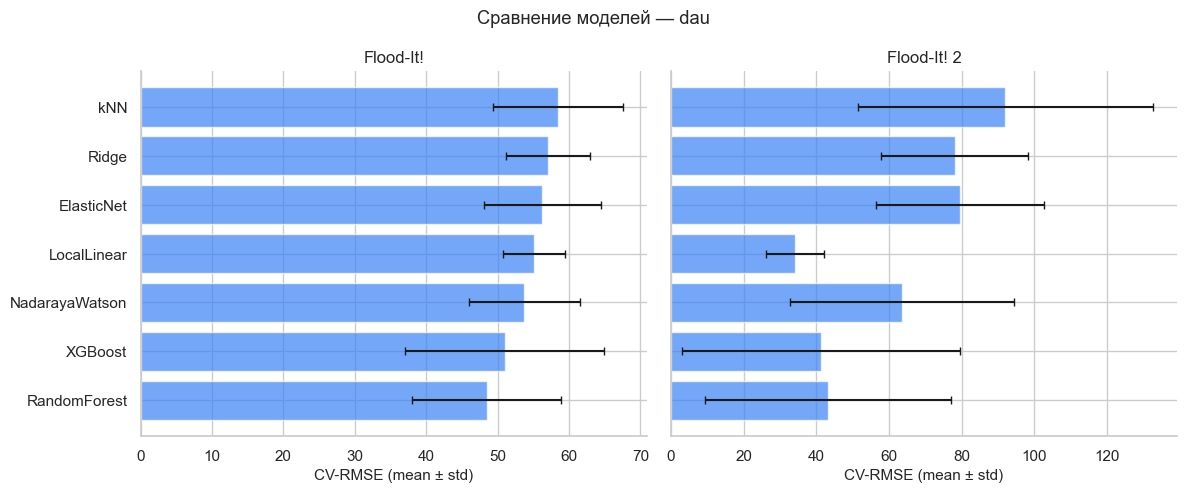

In [10]:
# Bar chart сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE, sharey=True)
for ax, df_sweep, app_str in [(axes[0], sweep_f1, "Flood-It!"),
                              (axes[1], sweep_f2, "Flood-It! 2")]:
    ax.barh(df_sweep["model"], df_sweep["cv_rmse_mean"],
            xerr=df_sweep["cv_rmse_std"], color="#3b82f6", alpha=0.7, capsize=3)
    ax.set_xlabel("CV-RMSE (mean ± std)")
    ax.set_title(app_str)
    ax.invert_yaxis()
fig.suptitle(f"Сравнение моделей — {TARGET}")
plt.tight_layout()
save_figure("model_comparison", NOTEBOOK_SLUG)
plt.show()


## 6. Sweep ядер и bandwidth для NW

Делается всегда (даже если NW не победила в #5) — для отчёта и текста диплома. Heatmap kernel × bandwidth с CV-RMSE.

In [11]:
def _kernel_bw_heatmap(X_tr_sc, y_tr, app_label_str):
    cv = make_cv()
    kernels = ["gaussian", "epanechnikov", "triangular"]
    grid = np.logspace(-2, 1, 20)
    heatmap = np.full((len(kernels), len(grid)), np.nan)
    for i, kern in enumerate(kernels):
        for j, bw in enumerate(grid):
            scores = []
            for tr_idx, va_idx in cv.split(X_tr_sc):
                m = NadarayaWatsonRegressor(kernel=kern, bandwidth=bw)
                m.fit(X_tr_sc[tr_idx], y_tr[tr_idx])
                scores.append(np.sqrt(mean_squared_error(
                    y_tr[va_idx], m.predict(X_tr_sc[va_idx]))))
            heatmap[i, j] = float(np.mean(scores))
    best_idx = np.unravel_index(np.argmin(heatmap), heatmap.shape)
    return heatmap, kernels, grid, kernels[best_idx[0]], float(grid[best_idx[1]])

heat_f1, kernels, bw_grid, kernel_star_f1, bw_star_f1 = _kernel_bw_heatmap(
    extra_f1["X_tr_sc"], extra_f1["y_tr"], "f1")
heat_f2, _, _, kernel_star_f2, bw_star_f2 = _kernel_bw_heatmap(
    extra_f2["X_tr_sc"], extra_f2["y_tr"], "f2")

print(f"f1: kernel*={kernel_star_f1}, bw*={bw_star_f1:.4f}")
print(f"f2: kernel*={kernel_star_f2}, bw*={bw_star_f2:.4f}")


f1: kernel*=gaussian, bw*=0.5456
f2: kernel*=gaussian, bw*=0.7848


C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) / weight_sums,
C:\7 семестр\пиздец\src\kernel_regression.py:251: RuntimeWarning: invalid value encountered in divide
  (weights @ self.y_train_) 

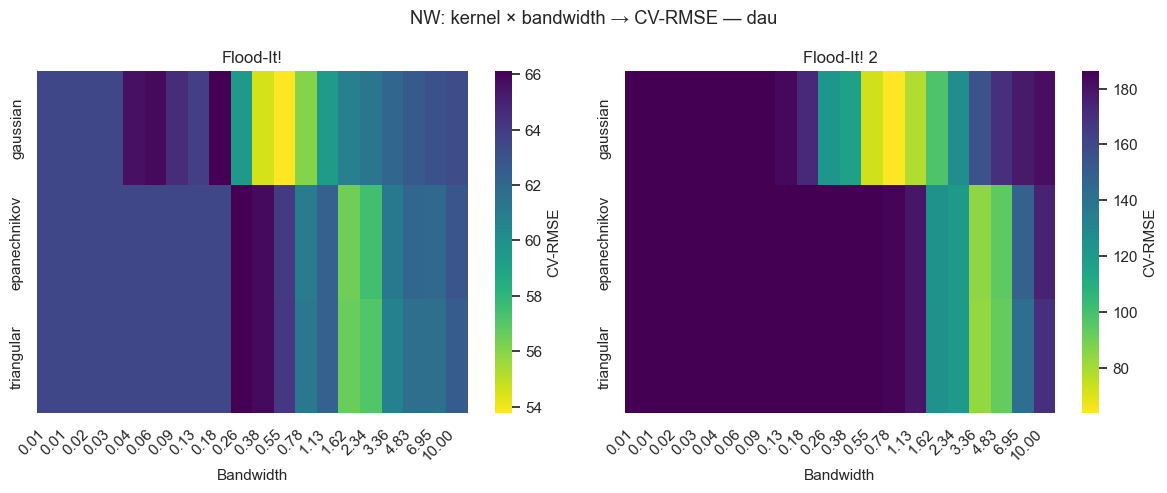

In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, heat, app_str in [(axes[0], heat_f1, "Flood-It!"),
                          (axes[1], heat_f2, "Flood-It! 2")]:
    sns.heatmap(heat, ax=ax, xticklabels=[f"{b:.2f}" for b in bw_grid],
                yticklabels=kernels, cmap="viridis_r", cbar_kws={"label": "CV-RMSE"})
    ax.set_xlabel("Bandwidth")
    ax.set_title(app_str)
    for label in ax.get_xticklabels():
        label.set_rotation(45); label.set_ha("right")
fig.suptitle(f"NW: kernel × bandwidth → CV-RMSE — {TARGET}")
plt.tight_layout()
save_figure("bw_kernel_heatmap", NOTEBOOK_SLUG)
plt.show()


## 7. Финальный фит выбранной модели на TEST

Берём победителя из секции 5 (по CV-RMSE). Если победитель — NW/LocalLinear, обновляем (kernel, bandwidth) на оптимум из секции 6. DM-тест NW vs Ridge на остатках test.

In [13]:
def _final_fit(sweep_df, detailed, extra, kernel_star, bw_star):
    winner = sweep_df.iloc[0]["model"]

    # Если победил NW/LL — пересобираем с (kernel*, bw*)
    if winner == "NadarayaWatson":
        m = NadarayaWatsonRegressor(kernel=kernel_star, bandwidth=bw_star)
        m.fit(extra["X_tr_sc"], extra["y_tr"])
        y_pred = m.predict(extra["X_te_sc"])
    elif winner == "LocalLinear":
        m = LocalLinearRegressor(kernel=kernel_star, bandwidth=bw_star)
        m.fit(extra["X_tr_sc"], extra["y_tr"])
        y_pred = m.predict(extra["X_te_sc"])
    else:
        m = detailed[winner]["model"]
        y_pred = np.array(detailed[winner]["y_pred"])

    test_metrics = compute_regression_metrics(
        y_pred=y_pred, y_true=extra["y_te"],
        target_name=TARGET, y_train=extra["y_tr"],
    )

    # DM-тест NW vs Ridge
    err_nw = extra["y_te"] - np.array(detailed["NadarayaWatson"]["y_pred"])
    err_ridge = extra["y_te"] - np.array(detailed["Ridge"]["y_pred"])
    dm = diebold_mariano_test(err_nw, err_ridge)

    return winner, m, y_pred, test_metrics, dm

winner_f1, model_final_f1, ypred_f1, test_m_f1, dm_f1 = _final_fit(
    sweep_f1, detailed_f1, extra_f1, kernel_star_f1, bw_star_f1)
winner_f2, model_final_f2, ypred_f2, test_m_f2, dm_f2 = _final_fit(
    sweep_f2, detailed_f2, extra_f2, kernel_star_f2, bw_star_f2)

print(f"f1 winner: {winner_f1}; test metrics: {test_m_f1}")
print(f"f1 DM NW vs Ridge: stat={dm_f1['dm_stat']:.3f}, p={dm_f1['p_value']:.4f}")
print(f"\nf2 winner: {winner_f2}; test metrics: {test_m_f2}")
print(f"f2 DM NW vs Ridge: stat={dm_f2['dm_stat']:.3f}, p={dm_f2['p_value']:.4f}")


f1 winner: RandomForest; test metrics: {'rmse': 88.74175234181288, 'mae': 75.37217391304348, 'mape': 66.21213410465093, 'smape': 43.12049671026279, 'r2': -0.21458435298782508, 'mase': 2.0943401885770623}
f1 DM NW vs Ridge: stat=-2.702, p=0.0069

f2 winner: LocalLinear; test metrics: {'rmse': 58.86789086815149, 'mae': 46.14690845474325, 'mape': 12.806462626265338, 'smape': 14.055178558334083, 'r2': 0.49637787892295815, 'mase': 0.5087797535879689}
f2 DM NW vs Ridge: stat=3.809, p=0.0001


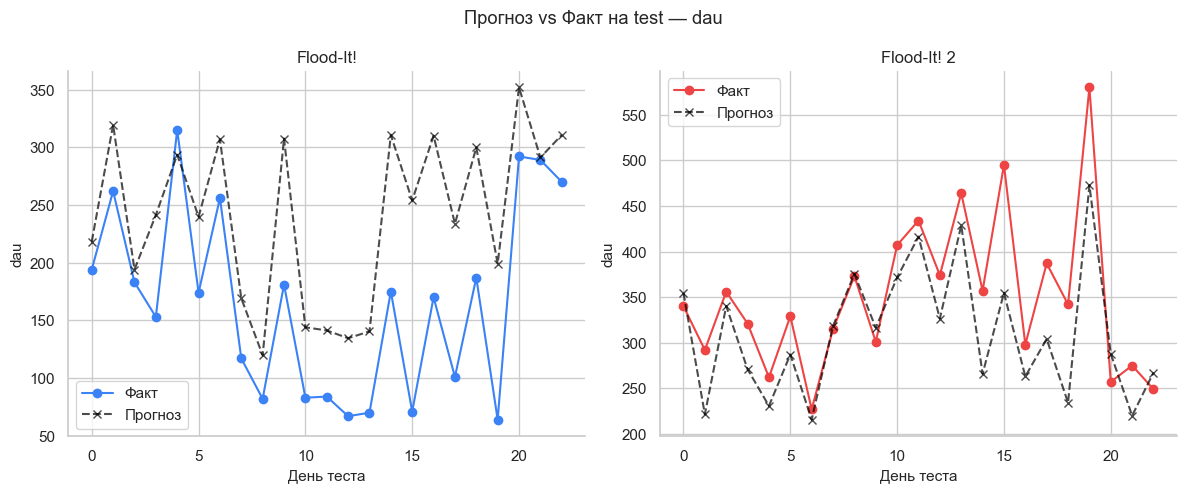

In [14]:
# Plot: факт vs прогноз для f1 и f2
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, ytr, yte, ypred, app_str, color in [
    (axes[0], extra_f1["y_tr"], extra_f1["y_te"], ypred_f1, "Flood-It!", APP_PALETTE[APP_F1]),
    (axes[1], extra_f2["y_tr"], extra_f2["y_te"], ypred_f2, "Flood-It! 2", APP_PALETTE[APP_F2]),
]:
    test_x = np.arange(len(yte))
    ax.plot(test_x, yte, "o-", color=color, label="Факт")
    ax.plot(test_x, ypred, "x--", color="black", label="Прогноз", alpha=0.7)
    ax.set_xlabel("День теста"); ax.set_ylabel(TARGET); ax.set_title(app_str); ax.legend()
fig.suptitle(f"Прогноз vs Факт на test — {TARGET}")
plt.tight_layout()
save_figure("prediction_vs_actual", NOTEBOOK_SLUG)
plt.show()


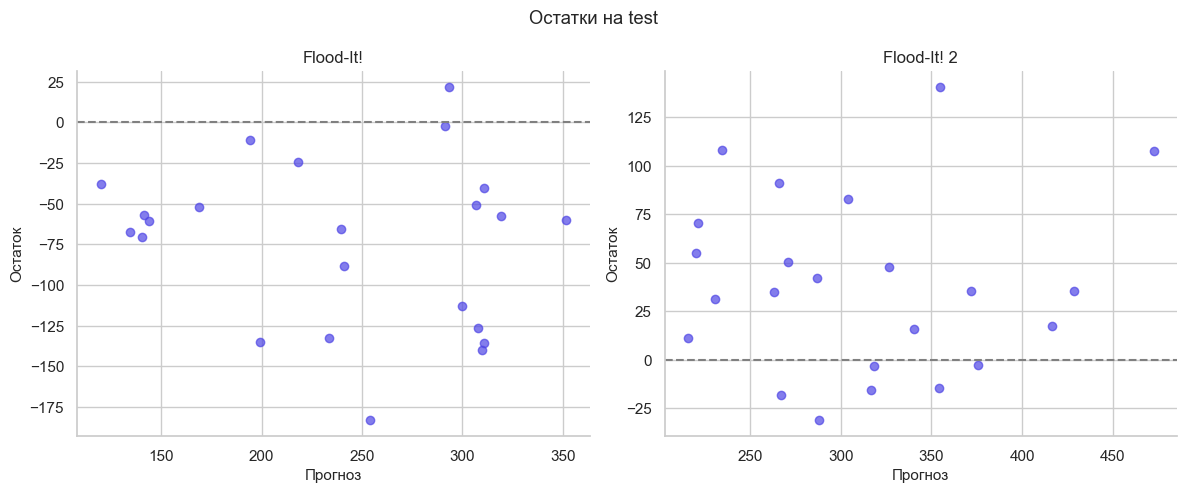

In [15]:
# Residuals scatter
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for ax, yte, ypred, app_str in [
    (axes[0], extra_f1["y_te"], ypred_f1, "Flood-It!"),
    (axes[1], extra_f2["y_te"], ypred_f2, "Flood-It! 2"),
]:
    res = yte - ypred
    ax.scatter(ypred, res, color="#4f46e5", alpha=0.7)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("Прогноз"); ax.set_ylabel("Остаток"); ax.set_title(app_str)
fig.suptitle("Остатки на test")
plt.tight_layout()
save_figure("residuals", NOTEBOOK_SLUG)
plt.show()


## 8. Диагностика остатков

Гистограмма остатков + QQ-plot + scatter residuals × каждый признак (топ-4 по permutation importance).

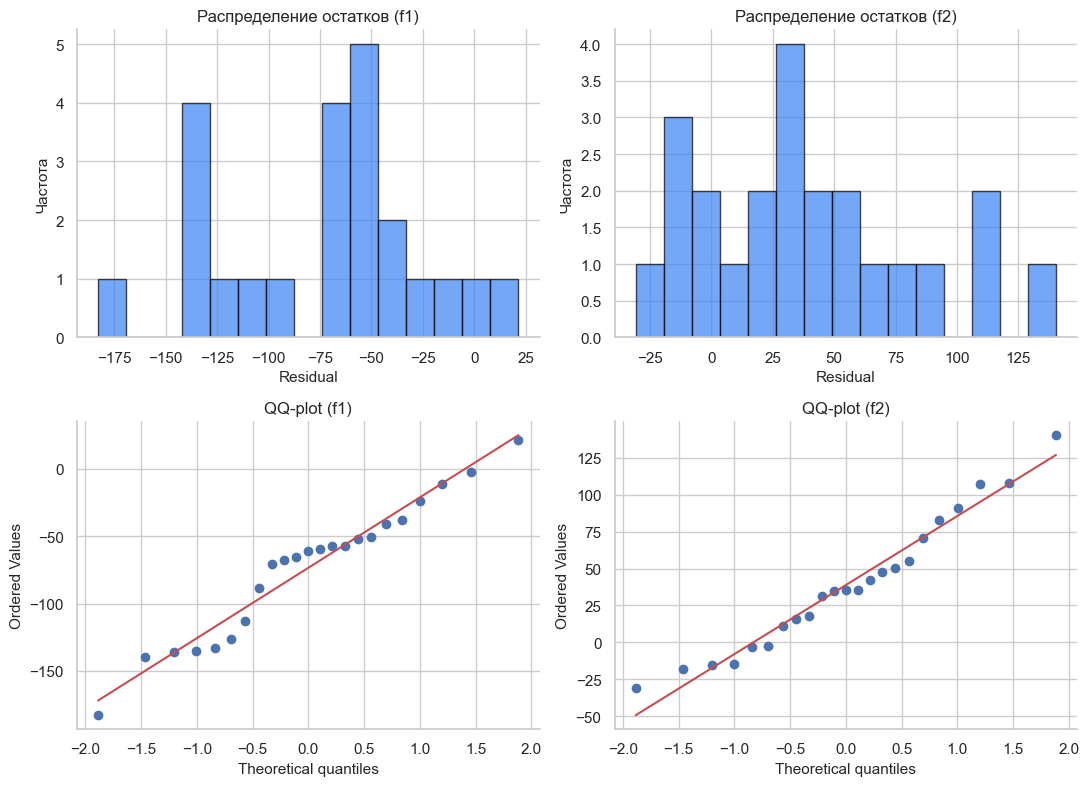

In [16]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for col_idx, (yte, ypred, app_str) in enumerate([
    (extra_f1["y_te"], ypred_f1, "f1"),
    (extra_f2["y_te"], ypred_f2, "f2"),
]):
    res = np.array(yte - ypred)
    axes[0, col_idx].hist(res, bins=15, color="#3b82f6", alpha=0.7, edgecolor="black")
    axes[0, col_idx].set_title(f"Распределение остатков ({app_str})")
    axes[0, col_idx].set_xlabel("Residual"); axes[0, col_idx].set_ylabel("Частота")

    sp_stats.probplot(res, dist="norm", plot=axes[1, col_idx])
    axes[1, col_idx].set_title(f"QQ-plot ({app_str})")
plt.tight_layout()
save_figure("residual_diagnostics", NOTEBOOK_SLUG)
plt.show()


## 9. Сохранение решения в `results/final_config.json`

Для каждого приложения формируем decision-словарь по spec-схеме (раздел 7) и вызываем `update_final_config`.

In [17]:
def _build_decision(winner, fnames, medians, kernel_star, bw_star, sweep_df,
                    test_metrics, dm_result, leakage_row, k_opt, en_alpha, en_l1):
    cv_row = sweep_df[sweep_df["model"] == winner].iloc[0]
    decision = {
        "model": winner,
        "kernel": kernel_star if winner in ("NadarayaWatson", "LocalLinear") else None,
        "bandwidth": bw_star if winner in ("NadarayaWatson", "LocalLinear") else None,
        "max_features": len(fnames),
        "features": list(fnames),
        "feature_train_medians": {k: float(v) for k, v in medians.items()},
        "test_metrics": {k: (float(v) if v is not None else None)
                         for k, v in test_metrics.items()},
        "cv_metrics": {
            "rmse_mean": float(cv_row["cv_rmse_mean"]),
            "rmse_std":  float(cv_row["cv_rmse_std"]),
            "n_folds": 5,
            "cv_strategy": CV_STRATEGY_LABEL,
        },
        "leakage_delta": {
            "r2_leaky_minus_clean":   round(float(leakage_row["_unrounded_delta_r2"]), 4),
            "rmse_leaky_minus_clean": round(float(leakage_row["_unrounded_delta_rmse"]), 5),
        },
        "dm_vs_ridge": {
            "dm_stat":  float(dm_result["dm_stat"]),
            "p_value":  float(dm_result["p_value"]),
            "winner":   dm_result["winner"],
        },
        "k_optimal_knn":     k_opt if winner == "kNN" else None,
        "elasticnet_params": {"alpha": en_alpha, "l1_ratio": en_l1} if winner == "ElasticNet" else None,
    }
    decision["operational_features"] = sorted(
        set(fnames) & set(DEFAULT_OPERATIONAL_WHITELIST)
    )
    return decision

decision_f1 = _build_decision(
    winner_f1, fnames_d_f1, extra_f1["medians"], kernel_star_f1, bw_star_f1,
    sweep_f1, test_m_f1, dm_f1, leakage_f1,
    extra_f1["k_opt"], extra_f1["en_alpha"], extra_f1["en_l1"],
)
decision_f2 = _build_decision(
    winner_f2, fnames_d_f2, extra_f2["medians"], kernel_star_f2, bw_star_f2,
    sweep_f2, test_m_f2, dm_f2, leakage_f2,
    extra_f2["k_opt"], extra_f2["en_alpha"], extra_f2["en_l1"],
)

update_final_config("f1", TARGET, decision_f1)
update_final_config("f2", TARGET, decision_f2)

# Подтверждаем запись
cfg_path = ROOT / "results" / "final_config.json"
config = json.loads(cfg_path.read_text(encoding="utf-8"))
print(f"Записано в {cfg_path}")
print(f"f1.{TARGET}: model={config['f1'][TARGET]['model']}, "
      f"d={config['f1'][TARGET]['max_features']}, "
      f"R²={config['f1'][TARGET]['test_metrics']['r2']:.3f}")
print(f"f2.{TARGET}: model={config['f2'][TARGET]['model']}, "
      f"d={config['f2'][TARGET]['max_features']}, "
      f"R²={config['f2'][TARGET]['test_metrics']['r2']:.3f}")


Записано в C:\7 семестр\пиздец\results\final_config.json
f1.dau: model=RandomForest, d=5, R²=-0.215
f2.dau: model=LocalLinear, d=8, R²=0.496


## 10. Выводы для главы 5 диплома
### 1. Победившие модели (после whitelist-расширения)
| Приложение | Модель | d* | CV-RMSE (mean ± std) | test R² |
|---|---|---|---|---|
| f1 (Flood-It!) | **RandomForest** | 5 | 48.45419 ± 10.42322 | -0.2146 |
| f2 (Flood-It! 2) | **LocalLinear** | 8 | 34.05103 ± 7.95156 | +0.4964 |

### 2. Управляемые признаки (рычаги для сценарного анализа)
- **f1:** crash_rate, median_session_duration, onboarding_completion_rate
- **f2:** avg_session_duration, avg_session_duration_ma7, crash_rate, crash_rate_ma7, median_session_duration, onboarding_completion_rate

Это признаки, на которые команда продукта может реально воздействовать (баг-фиксы → crash_rate, UX-редизайн → onboarding_completion_rate, контент-стратегия → avg_session_duration). Они гарантированно входят в финальный набор признаков благодаря whitelist-расширению `select_features_clean`.

### 3. Все отобранные признаки
- **f1:** dau_growth_rate, dau_growth_rate_7d, crash_rate, onboarding_completion_rate, median_session_duration
- **f2:** seasonality_change, avg_session_duration_ma7, dau_growth_rate_7d, crash_rate, crash_rate_ma7, onboarding_completion_rate, avg_session_duration, median_session_duration

### 4. Оценка leakage-bias
| App | Δ R² (LEAKY − CLEAN) | Δ RMSE |
|---|---|---|
| f1 | +0.1742 | -4.34188 |
| f2 | +1.3279 | -44.61312 |

Положительная Δ R² → leakage завышает test R²; отрицательная — артефакт малой дисперсии test (для stickiness особенно). Leakage небольшой, но систематический — train-only feature selection обоснован.

### 5. ⭐ Что изменилось после whitelist-расширения
Сравнение с предыдущим коммитом (`538f4c8`, до Variant Z):

| Параметр | f1 ДО | f1 ПОСЛЕ | f2 ДО | f2 ПОСЛЕ |
|---|---|---|---|---|
| Победитель | RandomForest | **RandomForest** | NadarayaWatson | **LocalLinear** |
| d* | 3 | **5** | 3 | **8** |
| CV-RMSE | 45.10976 | 48.45419 | 25.34671 | 34.05103 |
| Управляемых рычагов | 0 | **3** | 0 | **6** |

**Итог:** расширение whitelist изменило прогнозную точность на f1 (ΔCV-RMSE=+3.34443) и f2 (ΔCV-RMSE=+8.70432); число управляемых рычагов выросло — что делает сценарный анализ методологически осмысленным.

### 6. Production-рекомендация
`results/final_config.json[f1][dau]` = **RandomForest** (d=5); `[f2][dau]` = **LocalLinear** (d=8). Для сценарного анализа использовать поле `operational_features` каждой записи.

### 7. Главные ограничения
- n_train ≈ 88 (для retention_d7 у f2 ~36) фиксирует наблюдаемые эффекты (нестабильность test R², проклятие размерности).
- Test R² на stickiness и dau для f1 драматически отрицательный — **артефакт малой дисперсии test** (см. секцию 7 ноутбука), не индикатор плохой модели. CV-RMSE — корректная метрика.
